In [10]:
import pandas as pd
from pathlib import Path
# import tarfile
# import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_predict



In [4]:
import urllib.request
import os
import gzip
import numpy as np

os.makedirs("data/fashion", exist_ok=True)

urls = {
    "train_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz",
    "train_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz",
    "test_images":  "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz",
    "test_labels":  "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz"
}

for name, url in urls.items():
    path = f"data/fashion/{url.split('/')[-1]}"
    if not os.path.exists(path):
        print(f"Téléchargement de {url}...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"{path} existe déjà.")

def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        f.read(16)  
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(-1, 28, 28)

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        f.read(8)  
        return np.frombuffer(f.read(), dtype=np.uint8)
X_train = load_mnist_images("data/fashion/train-images-idx3-ubyte.gz")
y_train = load_mnist_labels("data/fashion/train-labels-idx1-ubyte.gz")
X_test  = load_mnist_images("data/fashion/t10k-images-idx3-ubyte.gz")
y_test  = load_mnist_labels("data/fashion/t10k-labels-idx1-ubyte.gz")

data/fashion/train-images-idx3-ubyte.gz existe déjà.
data/fashion/train-labels-idx1-ubyte.gz existe déjà.
data/fashion/t10k-images-idx3-ubyte.gz existe déjà.
data/fashion/t10k-labels-idx1-ubyte.gz existe déjà.


| y_train | Signification      |
| ------: | ------------------ |
|       0 | T-shirt / top      |
|       1 | Trouser (pantalon) |
|       2 | Pullover           |
|       3 | Dress              |
|       4 | Coat               |
|       5 | Sandal             |
|       6 | Shirt              |
|       7 | Sneaker            |
|       8 | Bag                |
|       9 | Ankle boot         |

In [ ]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [ ]:
X_train.shape

(60000, 28, 28)

In [5]:
X_train = X_train.reshape(-1,28*28)

In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [8]:
some_digit = X_train[0]

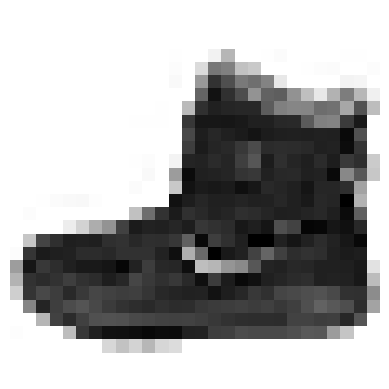

In [ ]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
plot_digit(some_digit)
plt.show()

In [ ]:
y_train[0]

np.uint8(9)

# Training a Binary Classifier

Let’s simplify the problem for now and only try to identify one digit—for
example, the number 5. This “5-detector” will be an example of a binary
classifier, capable of distinguishing between just two classes, 5 and non-5.

In [2]:
y_train_9 =(y_train == 9) # Sandal or not
y_test_9 = (y_test == 9)

In [3]:
y_train_9

array([ True, False, False, ..., False, False, False], shape=(60000,))

Now let’s pick a classifier and train it.

 A good place to start is with a
stochastic gradient descent (SGD, or stochastic GD) classifier, using Scikit-
Learn’s SGDClassifier class. 

>This classifier is capable of handling very
large datasets efficiently. This is in part because SGD deals with training
instances independently, one at a time, which also makes SGD well suited
for online learning.

## Full explanation: why SGD classifiers handle large datasets well



This classifier refers to a model trained using **Stochastic Gradient Descent (SGD)**, such as `SGDClassifier`.

Traditional learning algorithms usually train by looking at **the entire dataset at once**. This means they must:

* Load all training data into memory
* Perform heavy computations using all samples together

When the dataset is very large, this becomes **slow, memory-expensive, or even impossible**.

---

### How SGD works differently

SGD trains the model **incrementally**:

1. It takes **one training example** (one image, one row, one data point).
2. It computes the error for that single example.
3. It slightly updates the model parameters.
4. It moves to the next example and repeats.

Each training instance is treated **independently**, without waiting for all others.

---

### Why this is efficient for large datasets

Because SGD processes **one instance at a time**:

* **Memory usage stays very low**
  The algorithm does not need to store the full dataset in memory.

* **Training starts immediately**
  The model improves after each example, instead of waiting for a full pass over the data.

* **Computation per step is cheap**
  Each update is simple and fast.

This makes SGD capable of training on **millions of samples**.

---

### Why SGD is good for online learning

Online learning means:

* Data arrives continuously (streams, logs, sensors, user activity)
* The model must update itself **without retraining from scratch**

SGD naturally supports this because:

* New data can be processed **as soon as it arrives**
* The model keeps learning over time

---

### Final intuitive idea

SGD works like learning from experience **one example at a time**, instead of studying the entire book before making progress.
That is why it is **fast, memory-efficient, and scalable**, especially for very large or continuously growing datasets.

---




## SGDClassifier

In [ ]:
X_train.shape

(60000, 784)

In [ ]:
y_train_9.shape

(60000,)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42) # max_iter=2000
sgd_clf.fit(X_train,y_train_9)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


## Performance Measures

## Measuring Accuracy Using Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_9, cv=3,scoring="accuracy")

In [ ]:
from sklearn.dummy import DummyClassifier
"""
It’s a “fake” classifier that doesn’t actually learn from the data.

Instead, it makes predictions using simple rules.

The purpose is to create a baseline so you can check if your real model is actually doing better than random or naive strategies
"""
dummy_classifier = DummyClassifier()
cross_val_score(dummy_classifier, X_train, y_train_9, cv=3,scoring="accuracy")

>“Beats Nostradamus”

Just a humorous way to say:

- The model seems “predictive” (90% correct)

- But it is completely trivial

- Even a random fortune-teller (“Nostradamus”) couldn’t do better

## Confusion Matrices

`The general idea of a confusion matrix is to count the number of times instances of class A are classified as class B, for all A/B pairs. For example, to know the Anumber of times the classifier confused images of 8s with 0s, you would look at row #8, column #0 of the confusion matrix.`

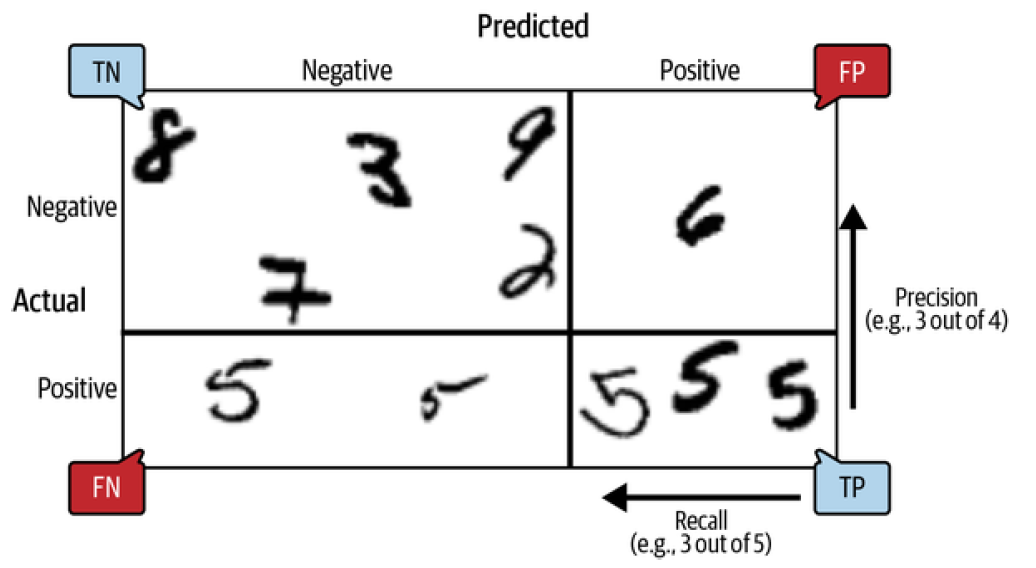

In [ ]:
"""
cross_val_predict() performs k-fold cross-validation, but instead of
returning the evaluation scores, it returns the predictions made on each test
fold. This means that you get a clean prediction for each instance in the
training set (by “clean” I mean “out-of-sample”: the model makes
predictions on data that it never saw during training).
"""
y_train_9_pred = cross_val_predict(sgd_clf,X_train,y_train_9)

In [8]:
y_train_9_pred

array([ True, False, False, ..., False, False, False], shape=(60000,))

In [9]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_train_9,y_train_9_pred)
conf_matrix

array([[53261,   739],
       [  631,  5369]])

## Precision and Recall

>precision = TP / (TP + FP)

A trivial way to have perfect precision is to create a classifier that always
makes negative predictions, except for one single positive prediction on the
instance it’s most confident about. If this one prediction is correct, then the
classifier has 100% precision (precision = 1/1 = 100%). Obviously, such a
classifier would not be very useful, since it would ignore all but one
positive instance. So, precision is typically used along with another metric
named recall, also called sensitivity or the true positive rate (TPR): this is
the ratio of positive instances that are correctly detected by the classifier

***Recall, or true positive rate:***

The true positive rate (TPR), or the proportion of all actual positives that were classified correctly as positives, is also known as recall.

`recall = TP / (TP + FN)`

In [ ]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_9,y_train_9_pred))
print(recall_score(y_train_9,y_train_9_pred))
# 0.879011132940406
# 0.8948333333333334

0.879011132940406
0.8948333333333334


>It is often convenient to combine precision and recall into a single metric
called the F score, especially when you need a single metric to compare
two classifiers. The F score is the harmonic mean of precision and recall
(Equation 3-3).

>Whereas the regular mean treats all values equally, the
harmonic mean gives much more weight to low values. As a result, the
classifier will only get a high F score if both recall and precision are high.


`F1 = 2 * recall * precision / (precision + recall)`

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_9, y_train_9_pred)
#0.8868516683184672

0.8868516683184672

`The F score favors classifiers that have similar precision and recall. This is not always what you want: in some contexts you mostly care about precision, and in other contexts you really care about recall. For example, if you trained a classifier to detect videos that are safe for kids, you would probably prefer a classifier that rejects many good videos (low recall) but keeps only safe ones (high precision), rather than a classifier that has a much higher recall but lets a few really bad videos show up in your product (in such cases, you may even want to add a human pipeline to check the classifier’s video selection). On the other hand, suppose you train a classifier to detect shoplifters in surveillance images: it is probably fine if your classifier only has 30% precision as long as it has 99% recall (sure, the security guards will get a few false alerts, but almost all shoplifters will get caught).`

>Unfortunately, you can’t have it both ways: increasing precision reduces recall, and vice versa. This is called the precision/recall trade-off.

## The Precision/Recall Trade-off

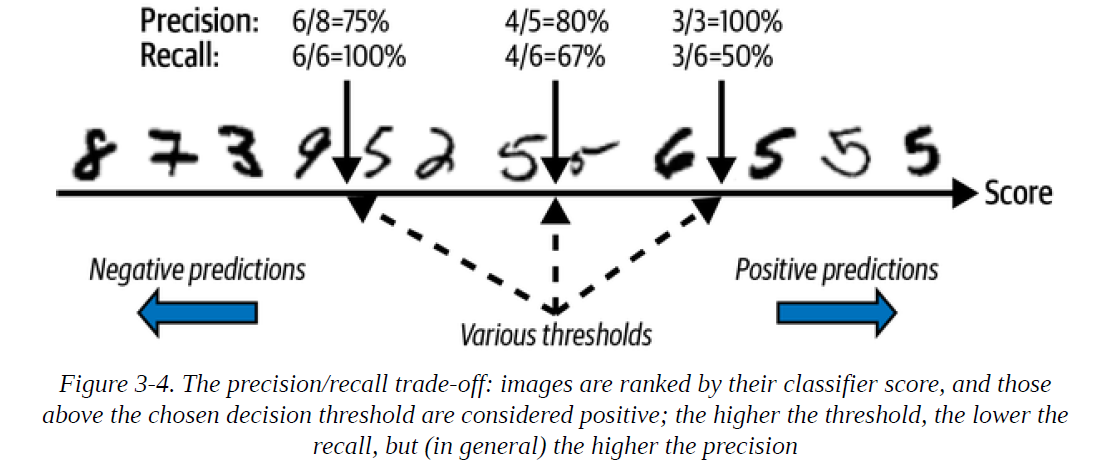


Suppose the decision
threshold is positioned at the central arrow (between the two 5s): you will
find 4 true positives (actual 5s) on the right of that threshold, and 1 false
positive (actually a 6). Therefore, with that threshold, the precision is 80%
(4 out of 5). But out of 6 actual 5s, the classifier only detects 4, so the recall
is 67% (4 out of 6). If you raise the threshold (move it to the arrow on the
right), the false positive (the 6) becomes a true negative, thereby increasing
the precision (up to 100% in this case), but one true positive becomes a
false negative, decreasing recall down to 50%. Conversely, lowering the
threshold increases recall and reduces precision.

>Scikit-Learn does not let you set the threshold directly, but it does give you
access to the decision scores that it uses to make predictions. Instead of
calling the classifier’s predict() method, you can call its
decision_function() method, which returns a score for each
instance, and then use any threshold you want to make predictions based on
those scores:

In [16]:
y_scores = sgd_clf.decision_function([some_digit])

In [17]:
y_scores

array([20064.7244281])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

"""
The SGDClassifier uses a threshold equal to 0, so the preceding code
returns the same result as the predict() method (i.e., True).
"""

array([ True])

`How do you decide which threshold to use? First, use the cross_val_predict() function to get the scores of all instances in the training set, but this time specify that you want to return decision scores instead of predictions:`

In [56]:
from sklearn.metrics import precision_recall_curve
y_scores = cross_val_predict(sgd_clf,X_train,y_train_9,cv=3,method="decision_function")

"""
With these scores, use the precision_recall_curve() function to
compute precision and recall for all possible thresholds (the function adds a
last precision of 0 and a last recall of 1, corresponding to an infinite
threshold):
"""
precisions, recalls, thresholds = precision_recall_curve(y_train_9, y_scores)

In [37]:
precisions

array([0.1       , 0.10000167, 0.10000333, ..., 1.        , 1.        ,
       1.        ], shape=(60001,))

In [ ]:
#

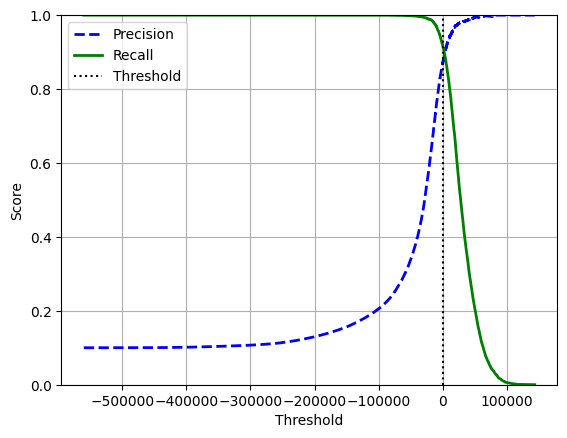

In [59]:
# plt.plot(thresholds, precisions[:-1], "b--", label="Precision",linewidth=2)
# plt.plot(thresholds, recalls[:-1], "g-", label="Recall",linewidth=2)
# plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
# plt.grid(True)
# plt.Circle([precisions,thresholds])
# plt.Circle([recalls,thresholds])
# plt.legend()


plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)

plt.vlines(threshold, 0, 1.0, colors="k", linestyles="dotted", label="Threshold")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.grid(True)
plt.legend()
plt.show()

# plt.bar_label(container=Bar)
plt.show()

In [ ]:
(precisions >= 0.90)

array([False, False, False, ...,  True,  True,  True], shape=(60001,))

In [ ]:
idx_for_90_precision = (precisions >= 0.90).argmax()
#This returns the first index of the maximum value
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3299.121278664238)

In [46]:
y_train_9_pred_90 = (y_scores >= threshold_for_90_precision)
y_train_9_pred_90

array([ True, False, False, ..., False, False, False], shape=(60000,))

In [47]:
y_train_9

array([ True, False, False, ..., False, False, False], shape=(60000,))

In [48]:
precision_score(y_train_9,y_train_9_pred_90)

0.9001349527665317

In [49]:
recall_score(y_train_9,y_train_9_pred_90)

0.8893333333333333

***TIP***
`If someone says, “Let’s reach 99% precision”, you should ask, “At what recall?”`

## The ROC Curve

The receiver operating characteristic (ROC) curve is another common tool
used with binary classifiers. It is very similar to the precision/recall curve,
but instead of plotting precision versus recall, the ROC curve plots the true
positive rate (another name for recall) against the false positive rate (FPR).
The FPR (also called the fall-out) is the ratio of negative instances that are
incorrectly classified as positive. It is equal to 1 – the true negative rate
(TNR), which is the ratio of negative instances that are correctly classified
as negative. The TNR is also called specificity. Hence, the ROC curve plots
sensitivity (recall) versus 1 – specificity.

In [50]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_9, y_scores)

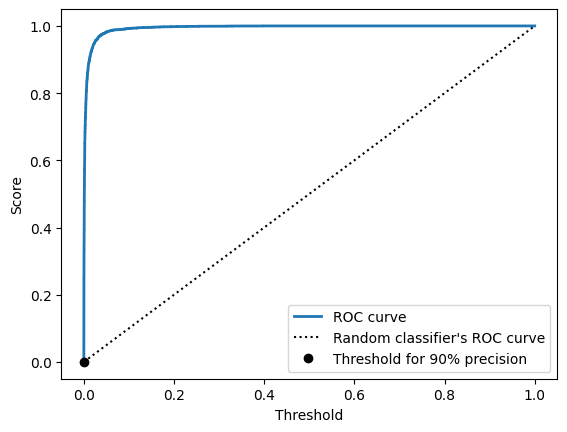

In [ ]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90],fpr[idx_for_threshold_at_90]
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.legend()
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.show()

`Once again there is a trade-off: the higher the recall (TPR), the more false positives (FPR) the classifier produces. The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).`

One way to compare classifiers is to measure the area under the curve
(AUC). A perfect classifier will have a ROC AUC equal to 1, whereas a
purely random classifier will have a ROC AUC equal to 0.5. Scikit-Learn
provides a function to estimate the ROC AUC:

In [52]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_9,y_scores)

0.9942057469135802

***--TIP--***

---

`Since the ROC curve is so similar to the precision/recall (PR) curve, you may wonder how to decide which one to use. As a rule of thumb, you should prefer the PR curve whenever the positive class is rare or when you care more about the false positives than the false negatives. Otherwise, use the ROC curve. For example, looking at the previous ROC curve (and the ROC AUC score), you may think that the classifier is really good. But this is mostly because there are few positives (5s) compared to the negatives (non- 5s). In contrast, the PR curve makes it clear that the classifier has room for improvement: the curve could really be closer to the top-right corner`

---

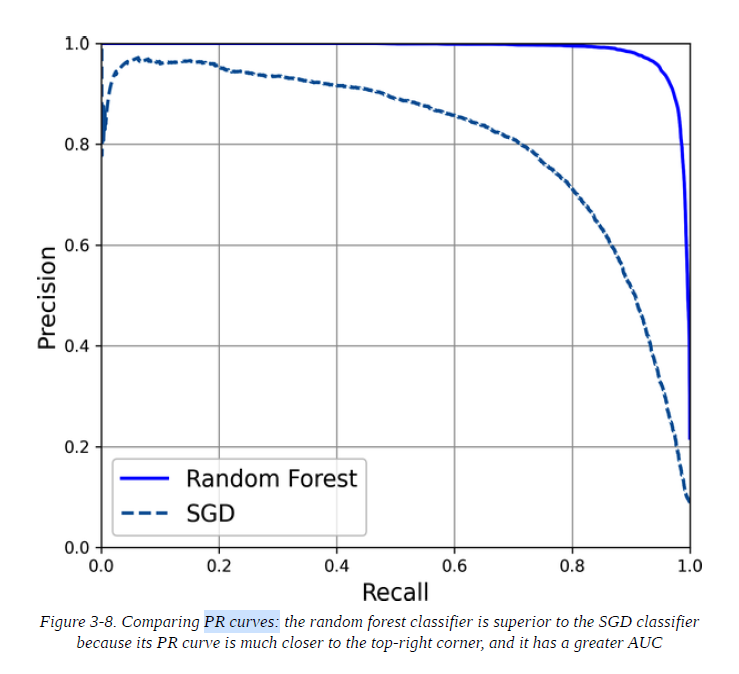

>the RandomForestClassifier’s PR
curve looks much better than the SGDClassifier’s: it comes much
closer to the top-right corner.

# Multiclass Classification

>multiclass
classifiers (also called multinomial classifiers) can distinguish between
more than two classes.

---

Some Scikit-Learn classifiers (e.g., LogisticRegression,
RandomForestClassifier, and GaussianNB) are capable of
handling multiple classes natively. Others are **strictly binary classifiers** (e.g.,
SGDClassifier and SVC). However, there are various strategies that
you can use to perform multiclass classification with multiple binary
classifiers.

---

One way to create a system that can classify the digit images into 10 classes
(from 0 to 9) is to train 10 binary classifiers, one for each digit (a 0-detector,
a 1-detector, a 2-detector, and so on). Then when you want to classify an
image, you get the decision score from each classifier for that image and
you select the class whose classifier outputs the highest score. This is called
the one-versus-the-rest (OvR) strategy, or sometimes one-versus-all (OvA).



**Does not understand!!!!!**


Another strategy is to train a binary classifier for every pair of digits: one to
distinguish 0s and 1s, another to distinguish 0s and 2s, another for 1s and
2s, and so on. This is called the one-versus-one (OvO) strategy. If there are
N classes, you need to train N × (N – 1) / 2 classifiers. For the MNIST
problem, this means training 45 binary classifiers! When you want to
classify an image, you have to run the image through all 45 classifiers and
see which class wins the most duels. The main advantage of OvO is that
each classifier only needs to be trained on the part of the training set
containing the two classes that it must distinguish.

`Some algorithms (such as support vector machine classifiers) scale poorly with the size of the training set. For these algorithms OvO is preferred because it is faster to train many classifiers on small training sets than to train few classifiers on large training sets. For most binary classification algorithms, however, OvR is preferred. Scikit-Learn detects when you try to use a binary classification algorithm for a multiclass classification task, and it automatically runs OvR or OvO, depending on the algorithm.`

In [ ]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000]) 

"""
Since there are 10 classes (i.e., more than 2), Scikit-Learn
used the OvO strategy and trained 45 binary classifiers.
"""
print(y_train[0])
svm_clf.predict([some_digit])

"""
This code actually made 45 predictions—one per pair of
classes—and it selected the class that won the most duels. If you call the
decision_function() method, you will see that it returns 10 scores
per instance: one per class. Each class gets a score equal to the number of
won duels plus or minus a small tweak (max ±0.33) to break ties, based on
the classifier scores
"""

svm_scores = svm_clf.decision_function([some_digit])

9


In [69]:
svm_scores = svm_clf.decision_function([some_digit])
svm_scores.round(2)

array([[ 1.72, -0.3 ,  2.77,  0.72,  3.76,  7.25,  5.05,  8.26,  6.28,
         9.31]])

In [ ]:
class_id = svm_scores.argmax()
print(class_id)
"""When a classifier is trained, it stores the list of target classes in its
classes_ attribute, ordered by value"""
print(svm_clf.classes_)

9
[0 1 2 3 4 5 6 7 8 9]


>If you want to force Scikit-Learn to use one-versus-one or one-versus-therest,
you can use the OneVsOneClassifier or
OneVsRestClassifier classes. Simply create an instance and pass a
classifier to its constructor (it doesn’t even have to be a binary classifier).
For example, this code creates a multiclass classifier using the OvR
strategy, based on an SVC:

In [72]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,estimator,SVC(random_state=42)
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [ ]:
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])
#len(ovr_clf.estimators_) 10

10

In [74]:
ovr_clf.predict([some_digit]) 


array([9], dtype=uint8)

In [75]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([9], dtype=uint8)

Simply scaling the inputs (as discussed in Chapter 2) increases
accuracy above 89.1%:

> from sklearn.preprocessing import StandardScaler

> scaler = StandardScaler()

> X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

> cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3,scoring="accuracy")

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train,y_train)


## Error Analysis

This confusion matrix looks
pretty good: most images are on the main diagonal, which means that they
were classified correctly.

c:\Users\dell\Downloads\machine learning\machine-learning-end-to-end-tp\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\dell\Downloads\machine learning\machine-learning-end-to-end-tp\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\dell\Downloads\machine learning\machine-learning-end-to-end-tp\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


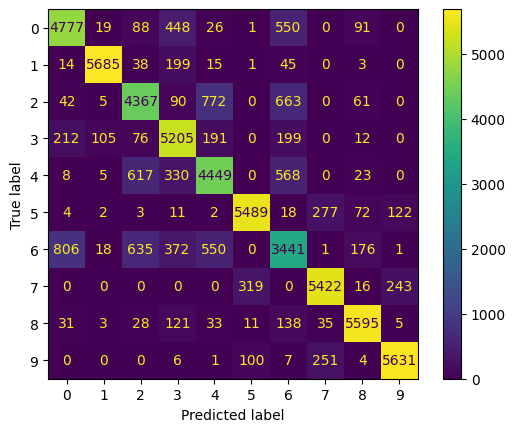

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled,y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

c:\Users\dell\Downloads\machine learning\machine-learning-end-to-end-tp\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\dell\Downloads\machine learning\machine-learning-end-to-end-tp\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\dell\Downloads\machine learning\machine-learning-end-to-end-tp\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


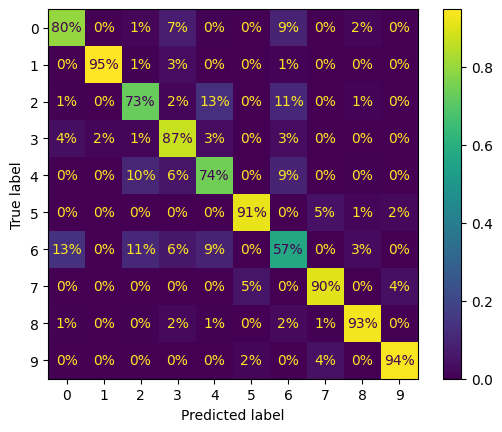

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled,y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,normalize="true",values_format=".0%")

"""
normalize the confusion matrix by dividing each value by the total number of images in
the corresponding (true) class (i.e., divide by the row’s sum). This can be
done simply by setting normalize="true". We can also specify the
values_format=".0%" argument to show percentages with no
decimals.
"""
plt.show()

`the 36% in row #7, column #9 does not mean that 36% of all images of 7s were misclassified as 9s. It means that 36% of the errors the model made on images of 7s were misclassifications as 9s.`

In [ ]:
"""
It is also possible to normalize the confusion matrix by column rather than
by row: if you set normalize="pred", you get the diagram on the right
in Figure 3-10. For example, you can see that 56% of misclassified 7s are
actually 9s.
"""
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled,y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,normalize="pred",values_format=".0%")

## Analyzing the confusion matrix

`It often gives you insights into ways to improve your classifier.`

**Looking at these plots, it seems that your efforts should be spent on reducing the false 8s.** 

>For example, you could try to : 

- gather more training data for digits that look like 8s (but are not) so that the
classifier can learn to distinguish them from real 8s.
- engineer new features that would help the classifier—for example, writing an algorithm to count the number of closed loops (e.g., 8 has two, 6 has one, 5 has none). 
- preprocess the images (e.g., using Scikit-Image, Pillow, or OpenCV) to make some patterns, such as closed loops, stand out more.

## Analyzing individual errors: 

`It can also be a good way to gain insights into what your classifier is doing and why it is failing.`
 
For example, let’s plot examples of 3s and 5s in a confusion matrix style

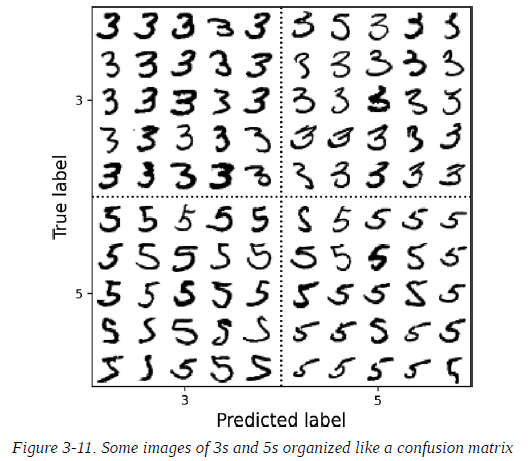


As you can see, some of the digits that the classifier gets wrong (i.e., in the
bottom-left and top-right blocks) are so badly written that even a human
would have trouble classifying them. However, most misclassified images
seem like obvious errors to us. It may be hard to understand why the
classifier made the mistakes it did, but remember that the human brain is a
fantastic pattern recognition system, and our visual system does a lot of
complex preprocessing before any information even reaches our
consciousness. So, the fact that this task feels simple does not mean that it
is. Recall that we used a simple SGDClassifier, which is just a linear
model: all it does is assign a weight per class to each pixel, and when it sees
a new image it just sums up the weighted pixel intensities to get a score for
each class. Since 3s and 5s differ by only a few pixels, this model will
easily confuse them.

The main difference between 3s and 5s is the position of the small line that
joins the top line to the bottom arc. If you draw a 3 with the junction
slightly shifted to the left, the classifier might classify it as a 5, and vice
versa. **In other words, this classifier is quite sensitive to image shifting and rotation**.

- One way to reduce the 3/5 confusion is to :

preprocess the images to ensure that they are well centered and not too rotated. However, this may
not be easy since it requires predicting the correct rotation of each image.

- A much simpler approach consists of :

`Augmenting the training set with slightly shifted and rotated variants of the training images. This will force the model to learn to be more tolerant to such variations. This is called data augmentation (we’ll cover this in Chapter 14; also see exercise 2 at the end of this chapter).`

# Multilabel Classification

Until now, each instance has always been assigned to just one class. But in
some cases you may want your classifier to output multiple classes for each
instance. Consider a face-recognition classifier: what should it do if it
recognizes several people in the same picture? It should attach one tag per
person it recognizes. Say the classifier has been trained to recognize three
faces: Alice, Bob, and Charlie. Then when the classifier is shown a picture
of Alice and Charlie, it should output [True, False, True]
(meaning “Alice yes, Bob no, Charlie yes”). Such a classification system
that outputs multiple binary tags is called a multilabel classification system.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
y_train_1 = (y_train >= 9)
y_train_2 = (y_train % 2 == 0)
y_multilabel = np.c_[y_train_1,y_train_2]
kn_cls = KNeighborsClassifier()

kn_cls.fit(X_train,y_multilabel)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
y_train[0]

np.uint8(9)

In [9]:
kn_cls.predict([some_digit])

array([[ True, False]])

3. Evaluating each label independently

The sentence says:

“One approach is to measure the F score for each individual label”

What this means: Treat each label as its own binary classifier

For each label:

- Positive = label present

- Negative = label absent

So for label k:

- Compute precisionₖ

- Compute recallₖ

- Compute F₁ₖ

This answers:

“How well does the model detect this specific label?”



## Averaging the scores (the key idea)

Once you compute an F-score for each label, you average them to get a single global metric.

This gives you an overall evaluation of the multilabel classifier.

>Common averaging strategies

- Macro average :Simple mean of F₁ scores. Treats all labels equally :Good when rare labels matter

- Weighted average: Weighted by label frequency, Frequent labels matter more

- Micro average : Computes global precision/recall first. Better when class imbalance is strong

>Why this approach makes sense

- Each label may have different difficulty

- Some labels may be well learned, others poorly

- Averaging per-label metrics gives a fair and interpretable evaluation

>Simple intuition

- Think of multilabel classification as:

- Many binary classifiers running in parallel

So it is natural to:

- Evaluate each binary classifier

- Combine their scores into one number

In [14]:
y_train_knn_pred = cross_val_predict(kn_cls, X_train,y_multilabel, cv=3)
f1_score(y_train,y_train_knn_pred)

NameError: name 'f1_score' is not defined

1. Classifier Chains

`Instead of training independent classifiers, we link them in a chain.`

>How the chain works

- Assume we have labels:
L₁ → L₂ → L₃ → ...

- The first classifier predicts L₁ using only the input features X

-The second classifier predicts L₂ using:

The original features X.

The prediction of L₁.

- The third classifier predicts L₃ using:

X

Predictions of L₁ and L₂

And so on…

`Each classifier knows what the previous ones predicted.`

2. Why this captures label dependencies

Because:

- Predictions of earlier labels become features for later labels

- The model can learn relationships like: 

“If the digit is large, it is probably odd”

“If label A is true, label B is more likely”

>So the model learns conditional dependencies between labels.

In [ ]:
from sklearn.multioutput import ClassifierChain
chain_clf = ClassifierChain(SVC(),cv = 3,random_state=42)
chain_clf.fit(X_train[:2000],y_multilabel[:2000])
chain_clf.predict([some_digit])

# Multioutput Classification

It is a
generalization of multilabel classification where each label can be
multiclass (i.e., it can have more than two possible values).

# Study the dataset

In [8]:
print(X_train.shape)
print(y_train.shape)
X_test = X_test.reshape(-1,784)
print(X_test.shape)
print(y_test.shape)


(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [11]:
df = pd.DataFrame(X_train)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Preprocesion

In [ ]:
#1.clean the missing value
df.isna().sum()[df.isna().sum()>0]
#no messing value

Series([], dtype: int64)

In [ ]:
#2.Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [ ]:
# 3. One-Hot Encode labels
# from tensorflow.keras.utils import to_categorical
# y = to_categorical(y_train, num_classes=10)

mathematically, a standard Logistic Regression is designed only for binary (Yes/No) choices. However, for datasets like Fashion-MNIST with 10 classes, Scikit-learn handles this automatically using one of two strategies.

1. The "One-vs-Rest" (OvR) Strategy
This is the default for Logistic Regression. Instead of one big model, the computer builds 10 separate mini-models behind the scenes.

Model 1: T-shirt vs. (Everything else)

Model 2: Trouser vs. (Everything else)

...and so on.

When you ask it to predict an image, all 10 models "vote." The class with the highest probability score wins.